In [1]:
import ssl

ssl._create_default_https_context = ssl._create_unverified_context

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from tensorflow.keras.preprocessing import image

# # Import all model classes and their corresponding preprocessing tools
# from tensorflow.keras.applications import (
#     DenseNet121,
#     EfficientNetV2B0,
#     InceptionV3,
#     MobileNetV2,
#     NASNetLarge,
#     NASNetMobile,
#     ResNet50,
#     ResNet50V2,
#     VGG16,
#     VGG19,
#     Xception,
# )
# from tensorflow.keras.applications.resnet_v2 import ResNet50V2, preprocess_input,decode_predictions
# from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input,preprocess_input,decode_predictions
# from tensorflow.keras.applications.vgg19 import VGG19, preprocess_input,decode_predictions
# from tensorflow.keras.applications.resnet_v2 import ResNet50V2,preprocess_input, decode_predictions
# from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input,decode_predictions
# from tensorflow.keras.applications.xception import preprocess_input,decode_predictions
# from tensorflow.keras.applications.inception_v3 import preprocess_input,decode_predictions
# from tensorflow.keras.applications.mobilenet_v2 import preprocess_input,decode_predictions
# from tensorflow.keras.applications.densenet import preprocess_input,decode_predictions
# from tensorflow.keras.applications.nasnet import preprocess_input,decode_predictions
# from tensorflow.keras.applications.nasnet import preprocess_input,decode_predictions
# from tensorflow.keras.applications.efficientnet_v2 import preprocess_input,decode_predictions


In [3]:
import ssl

# Fix SSL certificate verification for downloading weights
ssl._create_default_https_context = ssl._create_unverified_context

# Original import order preserved:
from tensorflow.keras.applications.resnet_v2 import (
    ResNet50V2,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.applications.vgg16 import (
    VGG16,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.applications.vgg19 import (
    VGG19,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.applications.resnet_v2 import (
    ResNet50V2,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.applications.resnet50 import (
    ResNet50,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.applications.xception import (
    Xception,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.applications.inception_v3 import (
    InceptionV3,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.applications.densenet import (
    DenseNet121,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.applications.nasnet import (
    NASNetLarge,
    NASNetMobile,
    decode_predictions,
    preprocess_input,
)
from tensorflow.keras.applications.efficientnet_v2 import (
    EfficientNetV2B0,
    decode_predictions,
    preprocess_input,
)

# Map model names to their respective classes
models_map = {
    "ResNet50V2": ResNet50V2,
    "VGG16": VGG16,
    "ResNet50": ResNet50,
    "VGG19": VGG19,
    "Xception": Xception,
    "InceptionV3": InceptionV3,
    "MobileNetV2": MobileNetV2,
    "DenseNet121": DenseNet121,
    "NASNetMobile": NASNetMobile,
    "NASNetLarge": NASNetLarge,
    "EfficientNetV2B0": EfficientNetV2B0,
}

# Dictionary to hold the loaded model instances
loaded_models = {}

# Loop to load each model one by one
for model_name, model_class in models_map.items():
    print(f"Loading {model_name}...")
    loaded_models[model_name] = model_class(weights="imagenet")
    print(f"Successfully loaded {model_name}!\n")

Loading ResNet50V2...
Successfully loaded ResNet50V2!

Loading VGG16...
Successfully loaded VGG16!

Loading ResNet50...
Successfully loaded ResNet50!

Loading VGG19...
Successfully loaded VGG19!

Loading Xception...
Successfully loaded Xception!

Loading InceptionV3...
Successfully loaded InceptionV3!

Loading MobileNetV2...
Successfully loaded MobileNetV2!

Loading DenseNet121...
Successfully loaded DenseNet121!

Loading NASNetMobile...
Successfully loaded NASNetMobile!

Loading NASNetLarge...
Successfully loaded NASNetLarge!

Loading EfficientNetV2B0...
Successfully loaded EfficientNetV2B0!



In [4]:
# # Load the ResNet50V2 model pre-trained on ImageNet data
# model = ResNet50V2(weights='imagenet')

# # Load the VGG16 model pre-trained on ImageNet data
# model = VGG16(weights='imagenet')

# # Load the ResNet50V2 model pre-trained on ImageNet data
# model = ResNet50V2(weights='imagenet')

# # Load the ResNet50 model pre-trained on ImageNet data
# model = ResNet50(weights='imagenet')

# # Load the VGG19 model pre-trained on ImageNet data
# model = VGG19(weights='imagenet')

# # Load the Xception model pre-trained on ImageNet data
# model = Xception(weights='imagenet')

# # Load the InceptionV3 model pre-trained on ImageNet data
# model = InceptionV3(weights='imagenet')

# # Load the MobileNetV2 model pre-trained on ImageNet data
# model = MobileNetV2(weights='imagenet')

# # Load the DenseNet121 model pre-trained on ImageNet data
# model = DenseNet121(weights='imagenet')

# # Load the NASNetMobile model pre-trained on ImageNet data
# model = NASNetMobile(weights='imagenet')

# # Load the NASNetLarge model pre-trained on ImageNet data
# model = NASNetLarge(weights='imagenet')

# # Load the EfficientNetV2B0 model pre-trained on ImageNet data
# model = EfficientNetV2B0(weights='imagenet')


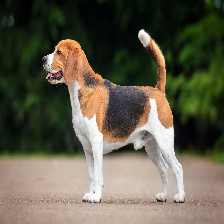

In [5]:

input_folder_path="/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/Keras_Packages/Input_Data"
output_folder_path ="/Users/chandra/Desktop/FSDS_GenAI_Training/FSDS_Classes/Python_Workspace/DeepLearning/Keras_Packages/temp_output"
image_path =input_folder_path+"/beagle-hound-dog.jpg"
img = image.load_img(r""+image_path,target_size=(224,224))


img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)
img

In [6]:
for model_name, model in loaded_models.items():
    print(f"--- Predicting with {model_name} ---")
    preds = model.predict(img_array)
    decod_preds = decode_predictions(preds, top=3)[0]
    print('Prediction')
    for i, (imagenet_id,label, score) in enumerate(decod_preds):
        print(f"{i+1} : {label} ({score:2f})")

--- Predicting with ResNet50V2 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
Prediction
1 : English_foxhound (0.999998)
2 : trifle (0.000002)
3 : fox_squirrel (0.000000)
--- Predicting with VGG16 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
Prediction
1 : Walker_hound (0.466765)
2 : English_foxhound (0.326222)
3 : bluetick (0.121010)
--- Predicting with ResNet50 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step
Prediction
1 : standard_poodle (0.257810)
2 : Walker_hound (0.232079)
3 : beagle (0.120744)
--- Predicting with VGG19 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
Prediction
1 : Walker_hound (0.346891)
2 : English_foxhound (0.272157)
3 : beagle (0.118490)
--- Predicting with Xception ---


ValueError: Input 0 with name 'input_layer_4' of layer 'xception' is incompatible with the layer: expected shape=(None, 299, 299, 3), found shape=(1, 224, 224, 3)